## 7. Social Vulnerability Analysis

This section uses ABS Census data to measure social vulnerability at the SA2 level. The indicators include median household income, elderly population percentage, children population percentage and population density. This part is later used as one input for the final priority intervention index.
### 7.1 Load packages and set folders

In [83]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

In [84]:
print(os.listdir("data/raw"))

# make folders for processed data and outputs
os.makedirs("data/processed", exist_ok=True)
os.makedirs("output/figures", exist_ok=True)
os.makedirs("output/tables", exist_ok=True)

['.DS_Store', 'open_space', 'urban_heat_cegetation_2018', 'abs_boundary', 'census_datapack']


### 7.2 Load and prepare SA2 boundary

In [72]:
boundary_files = []

for root, dirs, files in os.walk("data/raw/abs_boundary"):
    for file in files:
        if file.endswith(".shp") or file.endswith(".gpkg"):
            boundary_files.append(os.path.join(root, file))

boundary_files

['data/raw/abs_boundary/ASGS_2021_Main_Structure_GDA2020.gpkg']

In [71]:
# load boundary file
sa2 = gpd.read_file(boundary_files[0])

sa2.head()

,MB_CODE_2021,MB_CATEGORY_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA1_CODE_2021,SA2_CODE_2021,SA2_NAME_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,GCCSA_NAME_2021,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry
0,10000010000,Residential,0,No change,10901117207,109011172,Albury - East,10901,Albury,109,Murray,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,0.0209,http://linked.data.gov.au/dataset/asgsed3/MB/1...,"POLYGON ((146.92785 -36.08365, 146.92855 -36.0..."
1,10000021000,Commercial,0,No change,10901117612,109011176,Lavington,10901,Albury,109,Murray,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,0.0829,http://linked.data.gov.au/dataset/asgsed3/MB/1...,"POLYGON ((146.93543 -36.04752, 146.93448 -36.0..."
2,10000022000,Commercial,0,No change,10901117621,109011176,Lavington,10901,Albury,109,Murray,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,0.0388,http://linked.data.gov.au/dataset/asgsed3/MB/1...,"POLYGON ((146.93040 -36.04996, 146.93087 -36.0..."
3,10000023000,Commercial,0,No change,10901117621,109011176,Lavington,10901,Albury,109,Murray,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,0.0254,http://linked.data.gov.au/dataset/asgsed3/MB/1...,"POLYGON ((146.93254 -36.05238, 146.93288 -36.0..."
4,10000024000,Residential,0,No change,10901117613,109011176,Lavington,10901,Albury,109,Murray,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,0.0376,http://linked.data.gov.au/dataset/asgsed3/MB/1...,"POLYGON ((146.93044 -36.04733, 146.93118 -36.0..."


In [47]:
# keep Greater Melbourne only
melb_mb = sa2[sa2["GCCSA_NAME_2021"] == "Greater Melbourne"].copy()
melb_mb.head()

,MB_CODE_2021,MB_CATEGORY_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA1_CODE_2021,SA2_CODE_2021,SA2_NAME_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,GCCSA_NAME_2021,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry
114329,20015400000,Residential,0,No change,20901119918,209011199,Heidelberg West,20901,Banyule,209,Melbourne - North East,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,0.0125,http://linked.data.gov.au/dataset/asgsed3/MB/2...,"POLYGON ((145.05212 -37.75717, 145.05219 -37.7..."
114330,20015410000,Residential,0,No change,20901120346,209011203,Viewbank - Yallambie,20901,Banyule,209,Melbourne - North East,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,0.0271,http://linked.data.gov.au/dataset/asgsed3/MB/2...,"POLYGON ((145.09580 -37.73579, 145.09559 -37.7..."
114331,20015420000,Residential,0,No change,20901120316,209011203,Viewbank - Yallambie,20901,Banyule,209,Melbourne - North East,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,0.0443,http://linked.data.gov.au/dataset/asgsed3/MB/2...,"POLYGON ((145.09626 -37.73345, 145.09745 -37.7..."
114332,20015430000,Residential,0,No change,20901120318,209011203,Viewbank - Yallambie,20901,Banyule,209,Melbourne - North East,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,0.0456,http://linked.data.gov.au/dataset/asgsed3/MB/2...,"POLYGON ((145.10105 -37.73164, 145.10155 -37.7..."
114333,20015440000,Residential,0,No change,20901120012,209011200,Ivanhoe,20901,Banyule,209,Melbourne - North East,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,0.0245,http://linked.data.gov.au/dataset/asgsed3/MB/2...,"POLYGON ((145.03223 -37.75918, 145.03206 -37.7..."


The original ASGS file contains small spatial units, so I dissolved them into SA2 boundaries using SA2 code and SA2 name.

In [48]:
# dissolve small areas into SA2 boundary
sa2_melb = melb_mb.dissolve(
    by=["SA2_CODE_2021", "SA2_NAME_2021"],
    as_index=False)

sa2_melb.head()

,SA2_CODE_2021,SA2_NAME_2021,geometry,MB_CODE_2021,MB_CATEGORY_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA1_CODE_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,GCCSA_NAME_2021,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021
0,206011106,Brunswick East,"POLYGON ((144.97070 -37.77828, 144.97075 -37.7...",20460350000,Residential,0,No change,20601110609,20601,Brunswick - Coburg,206,Melbourne - Inner,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,0.0169,http://linked.data.gov.au/dataset/asgsed3/MB/2...
1,206011107,Brunswick West,"POLYGON ((144.93734 -37.77781, 144.93708 -37.7...",20460950000,Residential,0,No change,20601110706,20601,Brunswick - Coburg,206,Melbourne - Inner,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,0.0259,http://linked.data.gov.au/dataset/asgsed3/MB/2...
2,206011109,Pascoe Vale South,"POLYGON ((144.93338 -37.75181, 144.93207 -37.7...",20466240000,Residential,0,No change,20601110905,20601,Brunswick - Coburg,206,Melbourne - Inner,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,0.0263,http://linked.data.gov.au/dataset/asgsed3/MB/2...
3,206011495,Brunswick - North,"POLYGON ((144.95555 -37.76344, 144.95460 -37.7...",20460461000,Residential,0,No change,20601149503,20601,Brunswick - Coburg,206,Melbourne - Inner,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,0.0086,http://linked.data.gov.au/dataset/asgsed3/MB/2...
4,206011496,Brunswick - South,"POLYGON ((144.95167 -37.77700, 144.95030 -37.7...",20460490000,Residential,0,No change,20601149601,20601,Brunswick - Coburg,206,Melbourne - Inner,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,0.0167,http://linked.data.gov.au/dataset/asgsed3/MB/2...


In [49]:
sa2_melb = sa2_melb.rename(columns={
    "SA2_CODE_2021": "SA2_CODE",
    "SA2_NAME_2021": "SA2_NAME"})
sa2_melb = sa2_melb[["SA2_CODE", "SA2_NAME", "geometry"]]

sa2_melb.head()

,SA2_CODE,SA2_NAME,geometry
0,206011106,Brunswick East,"POLYGON ((144.97070 -37.77828, 144.97075 -37.7..."
1,206011107,Brunswick West,"POLYGON ((144.93734 -37.77781, 144.93708 -37.7..."
2,206011109,Pascoe Vale South,"POLYGON ((144.93338 -37.75181, 144.93207 -37.7..."
3,206011495,Brunswick - North,"POLYGON ((144.95555 -37.76344, 144.95460 -37.7..."
4,206011496,Brunswick - South,"POLYGON ((144.95167 -37.77700, 144.95030 -37.7..."


In [50]:
# project to a projected CRS for area calculation
sa2_melb = sa2_melb.to_crs(epsg=7855)

# calculate SA2 area in km2
sa2_melb["area_km2"] = sa2_melb.geometry.area / 1000000

sa2_melb[["SA2_CODE", "SA2_NAME", "area_km2"]].head()

,SA2_CODE,SA2_NAME,area_km2
0,206011106,Brunswick East,2.167998
1,206011107,Brunswick West,3.178667
2,206011109,Pascoe Vale South,2.988928
3,206011495,Brunswick - North,2.408738
4,206011496,Brunswick - South,2.733708


In [52]:
# save cleaned SA2 boundary
sa2_melb.to_file(
    "data/processed/sa2_melbourne_clean.gpkg",
    driver="GPKG"
)

### 7.3 Load Census tables
The Census G01 table was used for age and population variables. The G02 table was used for median weekly household income.

In [53]:
# read G01 and G02 census tables
g01 = pd.read_csv("data/raw/census_datapack/SA2/VIC/2021Census_G01_VIC_SA2.csv")
g02 = pd.read_csv("data/raw/census_datapack/SA2/VIC/2021Census_G02_VIC_SA2.csv")

g01.head()

,SA2_CODE_2021,Tot_P_M,Tot_P_F,Tot_P_P,Age_0_4_yr_M,Age_0_4_yr_F,Age_0_4_yr_P,Age_5_14_yr_M,Age_5_14_yr_F,Age_5_14_yr_P,...,High_yr_schl_comp_Yr_8_belw_P,High_yr_schl_comp_D_n_g_sch_M,High_yr_schl_comp_D_n_g_sch_F,High_yr_schl_comp_D_n_g_sch_P,Count_psns_occ_priv_dwgs_M,Count_psns_occ_priv_dwgs_F,Count_psns_occ_priv_dwgs_P,Count_Persons_other_dwgs_M,Count_Persons_other_dwgs_F,Count_Persons_other_dwgs_P
0,201011001,8188,8648,16835,623,585,1213,1453,1364,2815,...,430,23,22,45,7786,8263,16055,268,313,585
1,201011002,5711,6420,12131,267,224,490,658,630,1290,...,355,10,13,22,5152,5811,10969,755,766,1521
2,201011005,3594,3664,7261,190,172,357,561,587,1148,...,169,10,8,14,3308,3417,6722,217,215,435
3,201011006,5111,5553,10661,382,426,804,784,683,1464,...,408,22,13,39,4837,5211,10052,227,270,501
4,201011007,2172,2055,4230,125,99,223,338,326,668,...,126,4,3,8,2099,2013,4107,37,37,71


### 7.4 Prepare age and population indicators

In [58]:
g01_clean = g01.copy()
g01_clean["SA2_CODE"] = g01_clean["SA2_CODE_2021"].astype(str)

# calculate children population(children are defined as people aged 0 to 14)
g01_clean["children_pop"] = (
    g01_clean["Age_0_4_yr_P"] +
    g01_clean["Age_5_14_yr_P"])

# calculate elderly population(elderly people are defined as people aged 65 and over)
g01_clean["elderly_pop"] = (
    g01_clean["Age_65_74_yr_P"] +
    g01_clean["Age_75_84_yr_P"] +
    g01_clean["Age_85ov_P"])

# total population
g01_clean["total_population"] = g01_clean["Tot_P_P"]

# calculate percentage
g01_clean["children_pct"] = (
    g01_clean["children_pop"] / g01_clean["total_population"] * 100)

g01_clean["elderly_pct"] = (
    g01_clean["elderly_pop"] / g01_clean["total_population"] * 100)

g01_clean = g01_clean[["SA2_CODE",
        "children_pop",
        "elderly_pop",
        "total_population",
        "children_pct",
        "elderly_pct"]]

g01_clean.head()

,SA2_CODE,children_pop,elderly_pop,total_population,children_pct,elderly_pct
0,201011001,4028,2178,16835,23.926344,12.937333
1,201011002,1780,2826,12131,14.673151,23.295689
2,201011005,1505,1334,7261,20.727173,18.372125
3,201011006,2268,1578,10661,21.273802,14.801613
4,201011007,891,608,4230,21.063830,14.373522


Median weekly household income was selected as the income indicator. A lower income is later treated as higher vulnerability.

In [59]:
g02_clean = g02.copy()
g02_clean["SA2_CODE"] = g02_clean["SA2_CODE_2021"].astype(str)

# use median household income
g02_clean["median_income"] = g02_clean["Median_tot_hhd_inc_weekly"]

# keep useful columns
g02_clean = g02_clean[["SA2_CODE", "median_income"]]

g02_clean.head()

,SA2_CODE,median_income
0,201011001,1952
1,201011002,1573
2,201011005,1927
3,201011006,1627
4,201011007,2065


In [86]:
# merge age/population table with income table
census_clean = g01_clean.merge(
    g02_clean,
    on="SA2_CODE",
    how="left")

census_clean.head()

,SA2_CODE,children_pop,elderly_pop,total_population,children_pct,elderly_pct,median_income
0,201011001,4028,2178,16835,23.926344,12.937333,1952
1,201011002,1780,2826,12131,14.673151,23.295689,1573
2,201011005,1505,1334,7261,20.727173,18.372125,1927
3,201011006,2268,1578,10661,21.273802,14.801613,1627
4,201011007,891,608,4230,21.063830,14.373522,2065


In [61]:
# remove rows with missing values in selected indicators
census_clean = census_clean.dropna(
    subset=["children_pct", "elderly_pct", "total_population", "median_income"])

### 7.5 Join Census indicators to SA2 boundary

In [63]:
# merge census data with SA2 boundary
sa2_census = sa2_melb.merge(
    census_clean,
    on="SA2_CODE",
    how="left")

# calculate population density
sa2_census["population_density"] = (
    sa2_census["total_population"] / sa2_census["area_km2"])

sa2_census[[
        "SA2_CODE",
        "SA2_NAME",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"]].head()

,SA2_CODE,SA2_NAME,median_income,children_pct,elderly_pct,population_density
0,206011106,Brunswick East,2087.0,9.632595,8.800440,5875.465450
1,206011107,Brunswick West,1786.0,12.746194,12.292220,4504.403817
2,206011109,Pascoe Vale South,2245.0,18.209817,14.629451,3476.162532
3,206011495,Brunswick - North,2062.0,10.915438,11.567106,5351.348960
4,206011496,Brunswick - South,2126.0,9.381499,10.367404,4749.227012


In [87]:
# check missing values after joining
sa2_census[
    ["median_income", "children_pct", "elderly_pct", "population_density"]
].isna().sum()

median_income         2
children_pct          2
elderly_pct           2
population_density    2
dtype: int64

### 7.6 Calculate social vulnerability score

In [64]:
# function for min-max standardisation
def standardise(column):
    return (column - column.min()) / (column.max() - column.min())

# reverse standardisation
def reverse_standardise(column):
    return (column.max() - column) / (column.max() - column.min())

All indicators were standardised to a 0–1 scale before calculating the score. Income was reversed because lower income means higher vulnerability. Elderly percentage, children percentage and population density were treated as positive indicators, where higher values mean higher vulnerability or exposure.

In [78]:
# calculate vulnerability scores
sa2_census["income_score"] = reverse_standardise(sa2_census["median_income"])
sa2_census["elderly_score"] = standardise(sa2_census["elderly_pct"])
sa2_census["children_score"] = standardise(sa2_census["children_pct"])
sa2_census["density_score"] = standardise(sa2_census["population_density"])

# calculate final social vulnerability score
sa2_census["social_vulnerability_score"] = (
    sa2_census["income_score"] +
    sa2_census["elderly_score"] +
    sa2_census["children_score"] +
    sa2_census["density_score"]) / 4

**Table X. Top 10 SA2s with the highest social vulnerability score.**

In [89]:
# make top 10 social vulnerability table
top_social = sa2_census.sort_values(
    by="social_vulnerability_score",
    ascending=False
).head(10)

top_social_table = top_social[
    [ "SA2_NAME",
        "median_income",
        "elderly_pct",
        "children_pct",
        "population_density",
        "social_vulnerability_score"]].copy()

top_social_table

,SA2_NAME,median_income,elderly_pct,children_pct,population_density,social_vulnerability_score
357,Rosebud - McCrae,1155.0,33.372559,14.029812,964.207599,0.483841
360,Mornington - West,1389.0,38.701446,10.802382,1652.276704,0.478758
356,Point Nepean,1430.0,32.239665,13.871082,294.832994,0.446123
322,Melton,1061.0,20.213036,18.792797,799.431561,0.442654
25,Melbourne CBD - North,1089.0,1.920569,2.744517,30044.826477,0.440371
359,Mornington - East,1502.0,26.003295,17.930807,1033.186022,0.437449
351,Dromana,1398.0,30.734700,13.444561,296.654044,0.435837
173,Campbellfield - Coolaroo,1104.0,15.638039,21.679018,882.894531,0.432604
154,Avondale Heights,1587.0,26.727478,15.975137,2290.308512,0.430053
287,Kings Park (Vic.),1246.0,17.571337,18.665522,3154.552360,0.428325


In [90]:
top_social_table.to_csv(
    "output/tables/top_10_social_vulnerability_SA2.csv",
    index=False)

In [80]:
# save census indicators for later merge
sa2_census.drop(columns="geometry").to_csv(
    "data/processed/census_indicators_by_SA2.csv",
    index=False)

### 7.7 Map social vulnerability

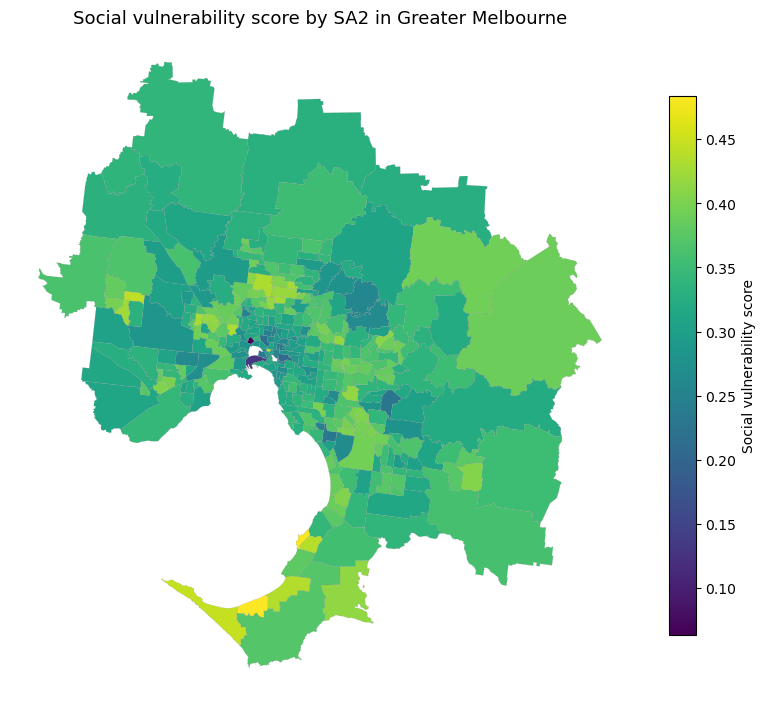

In [92]:
fig, ax = plt.subplots(figsize=(10, 10))

sa2_census.plot(
    column="social_vulnerability_score",
    legend=True,
    legend_kwds={
        "label": "Social vulnerability score",
        "shrink": 0.7},
    edgecolor="grey",
    linewidth=0.1,
    ax=ax)

ax.set_title("Social vulnerability score by SA2 in Greater Melbourne", fontsize=13)
ax.axis("off")

fig.savefig(
    "output/figures/social_vulnerability_map.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

**Figure X. Social vulnerability score by SA2 in Greater Melbourne.**  
Higher values show SA2s with higher social vulnerability based on weekly median household income, elderly population percentage, children population percentage and population density.